# Data analysis

Analysis of the Cashy dataset sample (`assets/datasets/S8.synthetic_cashy_sample.csv`). It load the cases and inspect how the scorecard components are used to obtain the final eligibility decision.

In [2]:
# Dependencies
%matplotlib inline

import csv
import html

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

filename = "assets/datasets/S8.synthetic_cashy_sample.csv"

with open(filename, "r") as file:
    reader = csv.DictReader(file)
    rows = list(reader)

cols = reader.fieldnames
data = [[row[col] for col in cols] for row in rows]


## Data visualization

This section groups all data visualization related scripts.

### Filters

Renders every case matching `filters`; it is a `{column: value}` dict. Values are matched exactly (leaving it empty keep all cases).

Edit `filters` and re-run the next cell to review the matching cases.

In [3]:
filters = {"month": "2023-10", "OficinaACNUR": "foten"} # {} keeps every case

new_data = [
    row for row in rows
    if all(row.get(key) == value for key, value in filters.items())
]

cols = list(rows[0].keys())

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in cols) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{row.get(col, '')}</td>" for col in cols) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

month,Elegibilidad,Vulnerability_Category,Demographics.HH.Head,Demographics.Language,Demographics.Profiles,Demographics.Documentation,Needs_and_Coping.BasicNeeds,Needs_and_Coping.Housing,Needs_and_Coping.Neg.mechanism,Needs_and_Coping.Dependency,OficinaACNUR,NumIntegrantes,dependencyCategory,FemaleHeadedHousehold,CuidadorSolo,HablaEspanol,Analfabeta_si,ScoreCOMAR_PIL,ScoreIntenciones,ScoreDuplicidad,Demographics_Score,NeedsandCoping_Score,Vulnerability_Score,FinalScore,EligibilityTarget
2023-10,Elegible,Vulnerabilidad Moderada,1.0,1.0,1.0,1.0,1.776038647,2.823478261,1.790108696,1.0,foten,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,,0,0,0.0,26.18890898,2.730928248,25.34612370011462,INCLUSION
2023-10,No Elegible,Vulnerabilidad Elevada,2.070141643,1.0,1.0,1.0,1.776038647,1.498900966,2.580217391,2.544987923,foten,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,-500.0,0,0,6.702282231,37.43330939,3.244257006,43.14663643599621,EXCLUSION
2023-10,No Elegible,Vulnerabilidad Baja,1.0,1.0,1.0,1.0,1.0,2.117608696,1.790108696,1.0,foten,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,,0,0,0.0,14.16503897,2.395343965,13.709193850906429,EXCLUSION
2023-10,No Elegible,Vulnerabilidad Elevada,2.700708215,1.0,1.249197356,1.0,1.776038647,2.117608696,1.790108696,1.043888889,foten,2,average,jefatura_masculina,no,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,11.93561888,22.50821784,2.983474979,34.10359991286824,EXCLUSION
2023-10,Lista de Reserva,Vulnerabilidad Severa,2.700708215,2.051104816,2.578385269,1.0,1.776038647,2.823478261,2.580217391,2.544987923,foten,2,average,jefatura_femenina,si,espanol_uno_mas_adultos,adultos_uno_mas_analfabeta,,0,0,31.71522481,50.0,4.339523636,81.12680245961062,EXCLUSION
2023-10,Elegible,Vulnerabilidad Severa,2.700708215,1.0,3.251728045,1.0,1.776038647,2.823478261,2.580217391,1.043888889,foten,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,24.2379543,32.85812825,3.63852919,56.81867673211505,INCLUSION
2023-10,Elegible,Vulnerabilidad Moderada,1.0,1.0,2.578385269,1.0,1.776038647,1.498900966,1.790108696,1.0,foten,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,8.975915299,17.10850297,2.744671614,25.82270346515955,INCLUSION
2023-10,Elegible,Vulnerabilidad Elevada,2.070141643,2.051104816,1.0,1.0,1.776038647,2.117608696,1.790108696,1.0,foten,1,low,,,espanol_uno_mas_adultos,adultos_uno_mas_analfabeta,0.0,0,0,14.63015408,21.88512181,3.046289687,36.28180377348088,INCLUSION
2023-10,No Elegible,Vulnerabilidad Elevada,1.0,1.0,2.578385269,1.0,1.776038647,2.117608696,2.580217391,1.043888889,foten,2,average,jefatura_masculina,no,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,,0,0,8.975915299,28.09152966,3.051206127,36.45228537324866,EXCLUSION
2023-10,No Elegible,Vulnerabilidad Elevada,1.0,1.0,3.251728045,1.0,1.776038647,2.823478261,2.580217391,1.0,foten,2,average,jefatura_femenina,si,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,11.51832969,32.12448674,3.23944252,42.97968968997395,EXCLUSION


### Columns

Renders every case with only the `columns` fields visible; it is a list of CSV field names, shown in the order they are listed (leaving it empty shows all of them).

Edit `columns` and re-run the next cell to review the rendered table.

In [4]:
columns = [ # empty list shows every column
    "month",
    "OficinaACNUR",
    "Vulnerability_Category",
    "FinalScore",
    "EligibilityTarget",
]

shown = columns or list(rows[0].keys())

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in shown) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{row.get(col, '')}</td>" for col in shown) +
        "</tr>"
        for row in rows
    ) +
    "</table>"
))

month,OficinaACNUR,Vulnerability_Category,FinalScore,EligibilityTarget
2024-06,sotap,Vulnerabilidad Baja,24.036863632451063,EXCLUSION
2023-09,foten,Vulnerabilidad Moderada,30.65974840868563,EXCLUSION
2023-11,pcr_cdmx,Vulnerabilidad Severa,59.79452340158775,EXCLUSION
2023-07,sotap,Vulnerabilidad Baja,19.481572780265047,EXCLUSION
2023-10,foten,Vulnerabilidad Moderada,25.34612370011462,INCLUSION
2023-11,sotap,Vulnerabilidad Elevada,40.685069357186286,INCLUSION
2023-10,sotap,Vulnerabilidad Elevada,34.61089292935174,INCLUSION
2024-03,sotap,Vulnerabilidad Moderada,28.173398221219387,EXCLUSION
2023-11,sotap,Vulnerabilidad Baja,11.62750948618979,EXCLUSION
2023-10,sotap,Vulnerabilidad Elevada,36.45228537324866,INCLUSION


### Inclusion / exclusion visualization

Renders every case whose `EligibilityTarget` equals `target` as a single table. Set `target` to `INCLUSION` or `EXCLUSION` and re-run the cell to switch sides.

In [5]:
target = 'INCLUSION' # EXCLUSION or INCLUSION

new_data = [
    row for row in rows
    if row.get("EligibilityTarget") == target
]

cols = list(rows[0].keys())

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in cols) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{row.get(col, '')}</td>" for col in cols) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

month,Elegibilidad,Vulnerability_Category,Demographics.HH.Head,Demographics.Language,Demographics.Profiles,Demographics.Documentation,Needs_and_Coping.BasicNeeds,Needs_and_Coping.Housing,Needs_and_Coping.Neg.mechanism,Needs_and_Coping.Dependency,OficinaACNUR,NumIntegrantes,dependencyCategory,FemaleHeadedHousehold,CuidadorSolo,HablaEspanol,Analfabeta_si,ScoreCOMAR_PIL,ScoreIntenciones,ScoreDuplicidad,Demographics_Score,NeedsandCoping_Score,Vulnerability_Score,FinalScore,EligibilityTarget
2023-10,Elegible,Vulnerabilidad Moderada,1.0,1.0,1.0,1.0,1.776038647,2.823478261,1.790108696,1.0,foten,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,,0,0,0.0,26.18890898,2.730928248,25.34612370011462,INCLUSION
2023-11,Elegible,Vulnerabilidad Elevada,1.0,1.525552408,2.578385269,1.0,1.776038647,2.117608696,2.580217391,1.0,sotap,3,average,jefatura_femenina,si,espanol_uno_mas_adultos,adultos_uno_mas_analfabeta,,0,0,13.7168894,27.40879931,3.173270511,40.685069357186286,INCLUSION
2023-10,Elegible,Vulnerabilidad Elevada,1.0,1.0,2.578385269,1.0,1.776038647,2.823478261,1.790108696,1.0,sotap,4,average,jefatura_femenina,si,espanol_uno_mas_adultos,adultos_uno_mas_analfabeta,0.0,0,0,8.975915299,26.18890898,2.998104289,34.61089292935174,INCLUSION
2023-10,Elegible,Vulnerabilidad Elevada,1.0,1.0,2.578385269,1.0,1.776038647,2.117608696,2.580217391,1.043888889,sotap,4,average,jefatura_femenina,no,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,8.975915299,28.09152966,3.051206127,36.45228537324866,INCLUSION
2023-12,Elegible,Vulnerabilidad Moderada,1.0,2.051104816,3.251728045,1.0,1.0,1.0,1.790108696,1.043888889,sotap,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,-500.0,0,0,20.39367297,6.061858428,2.776221171,26.9167435217761,INCLUSION
2023-12,Elegible,Vulnerabilidad Baja,1.0,1.0,1.0,1.0,1.776038647,2.117608696,1.0,1.0,sotap,3,average,jefatura_masculina,no,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,,0,0,0.0,14.06650994,2.392594036,13.61383558362086,INCLUSION
2023-08,Elegible,Vulnerabilidad Moderada,1.0,2.051104816,1.0,1.0,1.776038647,2.117608696,1.790108696,1.0,sotap,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,,0,0,6.609317356,21.88512181,2.807542403,28.002848502865827,INCLUSION
2023-09,Elegible,Vulnerabilidad Baja,1.0,1.0,1.0,1.0,1.0,2.117608696,1.790108696,1.0,sotap,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,0.0,14.16503897,2.395343965,13.709193850906429,INCLUSION
2023-08,Elegible,Vulnerabilidad Severa,2.700708215,1.0,2.578385269,1.0,1.776038647,2.823478261,2.580217391,1.0,fupal,5,high,jefatura_femenina,si,espanol_uno_mas_adultos,adultos_uno_mas_analfabeta,,-500,0,20.97871872,32.12448674,3.521039349,52.74452349934838,INCLUSION
2024-03,Elegible,Vulnerabilidad Baja,1.0,1.0,1.0,1.0,1.776038647,1.498900966,1.790108696,1.0,sotap,1,low,,,espanol_uno_mas_adultos,adultos_ninguno_analfabeta,0.0,0,0,0.0,17.10850297,2.477495573,16.55793423592243,INCLUSION


### Inclusion vs exclusion

Places one included case next to one excluded case, field by field, to see which scorecard components pushed them on opposite sides of the threshold.

Walk the dataset by re-running the cell after changing `inclusion_index` and `exclusion_index`. `inclusion_data` is sorted by `FinalScore` in descending order and `exclusion_data` in ascending order.

In [6]:
inclusion_index = 0
exclusion_index = 0

inclusion_data = [
    row for row in rows
    if row.get("EligibilityTarget") == "INCLUSION"
]

exclusion_data = [
    row for row in rows
    if row.get("EligibilityTarget") == "EXCLUSION"
]

html_table = """
<table border="1">
<tr>
    <th>Score</th>
    <th>Max Included</th>
    <th>Min Excluded</th>
</tr>
"""

inclusion_data.sort(reverse=True, key=lambda data: data["FinalScore"])
exclusion_data.sort(key=lambda data: data["FinalScore"])

for key in cols:
    html_table += f"""
    <tr>
        <td>{key}</td>
        <td>{inclusion_data[inclusion_index][key]}</td>
        <td>{exclusion_data[exclusion_index][key]}</td>
    </tr>
    """

html_table += "</table>"

display(HTML(html_table))

Score,Max Included,Min Excluded
month,2023-08,2024-06
Elegibilidad,Elegible,No Elegible
Vulnerability_Category,Vulnerabilidad Baja,Vulnerabilidad Baja
Demographics.HH.Head,2.700708215,1.0
Demographics.Language,1.0,1.0
Demographics.Profiles,1.0,1.0
Demographics.Documentation,1.0,1.0
Needs_and_Coping.BasicNeeds,1.0,1.0
Needs_and_Coping.Housing,1.0,1.0
Needs_and_Coping.Neg.mechanism,1.0,1.0


## Statistical analysis

The scores and the fields behind them are compared between the two sides of the decision, each one with a permutation p-value: the labels are shuffled 1000 times, and the gap is counted as often as a shuffle reproduces it. With 24 fields tested, only a p under 0.05 / 24 is worth reading.

The four measures used below:

- `d`: the gap between the two means over the spread of the field, signed, so a `d` of 0.1 means the included cases sit a tenth of a spread higher.
- `p`: how many of the 1000 shuffled labellings split the field at least this far, out of the 1000.
- `chi2`: how far the counts of a field sit from the counts its group sizes alone would give, so the bigger the gap the worse the fit.
- `AUC`: how often an included case outscores an excluded one, where 0.5 is a coin and 1.0 a field that separates the two sides on its own.

The acronyms in the field names:

- `ACNUR`: the UN refugee agency, so `OficinaACNUR` is the branch that took the case in, one of seven codes.
- `COMAR`: the Mexican commission that registers refugees, the body behind `ScoreCOMAR_PIL`.
- `PIL`: part of that score name. In this sample it is 0, 500 or -500, and blank on half the cases.

In [7]:
scores = [ # every field that carries a number
    "Demographics.HH.Head",
    "Demographics.Language",
    "Demographics.Profiles",
    "Demographics.Documentation",
    "Needs_and_Coping.BasicNeeds",
    "Needs_and_Coping.Housing",
    "Needs_and_Coping.Neg.mechanism",
    "Needs_and_Coping.Dependency",
    "NumIntegrantes",
    "ScoreCOMAR_PIL",
    "ScoreIntenciones",
    "ScoreDuplicidad",
    "Demographics_Score",
    "NeedsandCoping_Score",
    "Vulnerability_Score",
    "FinalScore",
]

categories = [ # every field that does not
    "month",
    "Vulnerability_Category",
    "OficinaACNUR",
    "dependencyCategory",
    "FemaleHeadedHousehold",
    "CuidadorSolo",
    "HablaEspanol",
    "Analfabeta_si",
]

labels = np.array([row["EligibilityTarget"] == "INCLUSION" for row in rows])

numeric = { # an empty penalty reads as no penalty
    name: np.array([float(row[name] or 0) for row in rows])
    for name in scores
}

new_data = [
    ("Cases", f"{labels.sum()}", f"{(~labels).sum()}"),
    ("Share of the cases", f"{labels.mean():.1%}", f"{1 - labels.mean():.1%}"),
    *[
        (
            name,
            f"{values[labels].mean():.2f} (sd {values[labels].std():.2f})",
            f"{values[~labels].mean():.2f} (sd {values[~labels].std():.2f})",
        )
        for name, values in numeric.items()
    ],
]

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Score", "INCLUSION", "EXCLUSION")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

Score,INCLUSION,EXCLUSION
Cases,427,1473
Share of the cases,22.5%,77.5%
Demographics.HH.Head,1.43 (sd 0.67),1.47 (sd 0.68)
Demographics.Language,1.16 (sd 0.34),1.15 (sd 0.34)
Demographics.Profiles,1.71 (sd 0.88),1.63 (sd 0.85)
Demographics.Documentation,1.02 (sd 0.11),1.02 (sd 0.11)
Needs_and_Coping.BasicNeeds,1.59 (sd 0.33),1.56 (sd 0.35)
Needs_and_Coping.Housing,2.05 (sd 0.71),1.97 (sd 0.71)
Needs_and_Coping.Neg.mechanism,1.92 (sd 0.53),1.91 (sd 0.55)
Needs_and_Coping.Dependency,1.09 (sd 0.30),1.10 (sd 0.33)


### Scores by target

Every numeric field next to the cases on each side, with the spread behind each mean. The columns overlap: the included cases even score higher on `FinalScore`, and the three penalties are the only fields where the excluded cases are worse off.

The next table asks whether any of that is real.

In [8]:
rng = np.random.default_rng(0) # same seed, so the p-values do not move between runs

shuffled = np.array([rng.permutation(labels) for _ in range(1000)])

new_data = []
for name, values in numeric.items():
    difference = values[labels].mean() - values[~labels].mean()
    spread = np.sqrt((values[labels].var() + values[~labels].var()) / 2)
    sizes = shuffled.sum(axis=1)
    counted = shuffled @ values
    null = counted / sizes - (values.sum() - counted) / (len(values) - sizes)
    p = (np.abs(null) >= abs(difference)).sum()
    new_data.append((
        name,
        f"{difference:+.2f}",
        f"{difference / spread:+.3f}",
        f"{(p + 1) / (len(null) + 1):.3f}",
    ))

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Field", "Difference", "d", "p")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

Field,Difference,d,p
Demographics.HH.Head,-0.03,-0.051,0.344
Demographics.Language,+0.01,+0.026,0.637
Demographics.Profiles,+0.08,+0.095,0.080
Demographics.Documentation,-0.00,-0.010,0.782
Needs_and_Coping.BasicNeeds,+0.04,+0.104,0.067
Needs_and_Coping.Housing,+0.08,+0.106,0.049
Needs_and_Coping.Neg.mechanism,+0.01,+0.020,0.719
Needs_and_Coping.Dependency,-0.01,-0.020,0.709
NumIntegrantes,+0.04,+0.028,0.617
ScoreCOMAR_PIL,+16.14,+0.119,0.032


### Categorical fields

Inclusion rate per value, then how unevenly those values split the two sides.

Every field describing the household sits around the 22.5% of the whole sample. `month` does not: 2.7% to 43.6% across the fourteen months, and the only field of the twenty-four over the 0.05 / 24 line.

In [9]:
def chi_square(counts):
    """Distance between the observed counts of a 2 x k table and the counts it assumes."""
    total = counts.sum()
    expected = counts.sum(axis=1)[:, None] * counts.sum(axis=0) / total
    return np.divide(
        (counts - expected) ** 2,
        expected,
        out=np.zeros_like(expected, dtype=float),
        where=expected > 0, # a level that never shows up on one side adds nothing
    ).sum()

new_data = []
test_data = []
for field in categories:
    levels = list(dict.fromkeys(row[field] for row in rows)) # the order the cases list them in
    onehot = np.array([[row[field] == level for level in levels] for row in rows])
    observed = chi_square(np.array([onehot[labels].sum(axis=0), onehot[~labels].sum(axis=0)]))
    null = np.array([
        chi_square(np.array([onehot[shuffle].sum(axis=0), onehot[~shuffle].sum(axis=0)]))
        for shuffle in shuffled
    ])
    test_data.append((
        field,
        f"{observed:.1f}",
        f"{((null >= observed).sum() + 1) / (len(null) + 1):.3f}",
    ))
    new_data += [
        (
            field,
            levels[level] or "(blank)",
            f"{onehot[:, level].sum()}",
            f"{onehot[labels, level].sum()}",
            f"{onehot[labels, level].sum() / onehot[:, level].sum():.1%}",
        )
        for level in range(len(levels))
    ]

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Field", "Value", "Cases", "Included", "Rate")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Field", "chi2", "p")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in test_data
    ) +
    "</table>"
))

Field,Value,Cases,Included,Rate
month,2024-06,146,4,2.7%
month,2023-09,121,29,24.0%
month,2023-11,112,41,36.6%
month,2023-07,160,7,4.4%
month,2023-10,138,44,31.9%
month,2024-03,134,41,30.6%
month,2023-06,84,3,3.6%
month,2024-02,175,54,30.9%
month,2024-04,174,20,11.5%
month,2024-05,187,23,12.3%


Field,chi2,p
month,200.0,0.001
Vulnerability_Category,3.7,0.293
OficinaACNUR,3.2,0.884
dependencyCategory,2.0,0.577
FemaleHeadedHousehold,0.1,0.960
CuidadorSolo,1.3,0.521
HablaEspanol,0.1,0.835
Analfabeta_si,2.2,0.165


### The label behind the target

`EligibilityTarget` is `Elegibilidad` split in two, every `Elegible` case an `INCLUSION` and every other label an `EXCLUSION`. The score does not follow the label either: 26.75 on average for a `Lista de Reserva` case against 28.92 for an `Elegible` one, both spreading from 0 to over 76.

In [10]:
new_data = []
for label in dict.fromkeys(row["Elegibilidad"] for row in rows):
    cases = np.array([row["Elegibilidad"] == label for row in rows])
    final = numeric["FinalScore"][cases]
    new_data.append((
        label,
        f"{cases.sum()}",
        f"{labels[cases].sum()}",
        f"{(~labels[cases]).sum()}",
        f"{final.mean():.2f}",
        f"{final.min():.1f} - {final.max():.1f}",
    ))

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Elegibilidad", "Cases", "INCLUSION", "EXCLUSION", "Mean score", "Score range")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

Elegibilidad,Cases,INCLUSION,EXCLUSION,Mean score,Score range
No Elegible por Duplicidad,38,0,38,28.56,0.0 - 68.6
Lista de Reserva,451,0,451,26.75,0.0 - 81.1
No Elegible,932,0,932,27.80,0.0 - 76.8
Elegible,414,414,0,28.92,0.0 - 76.8
No Elegible por Intenciones,52,0,52,26.96,3.7 - 67.6
Elegible por Proceso Acelerado,13,13,0,21.47,0.0 - 33.5


### The score as a decision rule

If `FinalScore` carried the decision, one cut would separate the two sides. Its AUC sits at 0.529, and the best cut over every value of the score is not one point better than excluding all 1900 cases. 44.7% of the inclusions score below the median of the exclusions.

The figure says the same twice: the two distributions lie on top of each other, and the rate per tenth of the score wobbles around 22.5%.

Score,AUC
Demographics_Score,0.515
NeedsandCoping_Score,0.524
Vulnerability_Score,0.529
FinalScore,0.529


Rule,Accuracy,Cut
Always EXCLUDE,77.5%,-
Always INCLUDE,22.5%,-
Best cut on FinalScore,77.5%,above every score


RuntimeError: 'xelatex' not found; install it or change rcParams['pgf.texsystem'] to an available TeX implementation

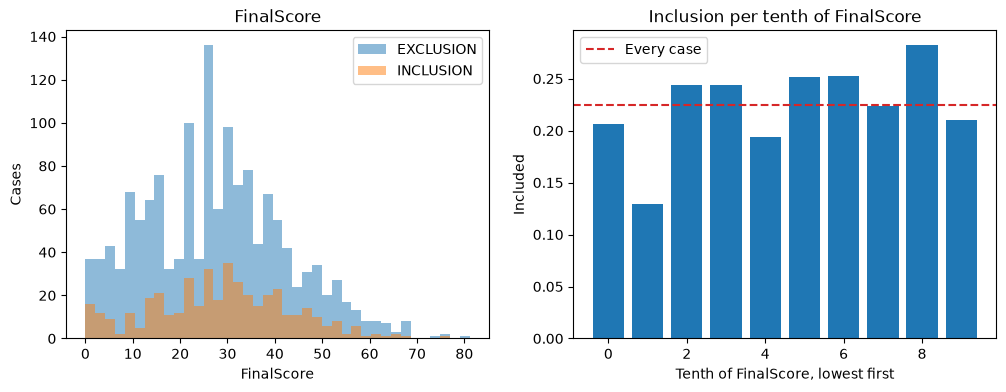

In [11]:
final = numeric["FinalScore"]

new_data = [
    (
        name,
        f"{(values[labels, None] > values[~labels]).mean() + (values[labels, None] == values[~labels]).mean() / 2:.3f}",
    )
    for name, values in numeric.items()
    if name.endswith("_Score") or name == "FinalScore"
]

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Score", "AUC")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in new_data
    ) +
    "</table>"
))

cuts = np.append(np.unique(final), np.inf) # np.inf cuts above every score, so it includes nothing
correct = [(((final >= cut) == labels).mean(), cut) for cut in cuts]
best, cut = max(correct)

display(HTML(
    "<table border='1'>" +
    "<tr>" +
    "".join(f"<th>{col}</th>" for col in ("Rule", "Accuracy", "Cut")) +
    "</tr>" +
    "".join(
        "<tr>" +
        "".join(f"<td>{cell}</td>" for cell in row) +
        "</tr>"
        for row in [
            ("Always EXCLUDE", f"{(~labels).mean():.1%}", "-"),
            ("Always INCLUDE", f"{labels.mean():.1%}", "-"),
            ("Best cut on FinalScore", f"{best:.1%}", f"{cut:.1f}" if np.isfinite(cut) else "above every score"),
        ]
    ) +
    "</table>"
))

figure, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, final.max(), 40)
left.hist(final[~labels], bins=bins, alpha=0.5, label="EXCLUSION")
left.hist(final[labels], bins=bins, alpha=0.5, label="INCLUSION")
left.set(title="FinalScore", xlabel="FinalScore", ylabel="Cases")
left.legend()

tenths = np.digitize(final, np.quantile(final, np.linspace(0, 1, 11))[1:-1])
right.bar(
    range(10),
    [labels[tenths == tenth].mean() for tenth in range(10)],
    color="C0",
)
right.axhline(labels.mean(), ls="--", c="C3", label="Every case")
right.set(
    title="Inclusion per tenth of FinalScore",
    xlabel="Tenth of FinalScore, lowest first",
    ylabel="Included",
)
right.legend()

plt.tight_layout()
plt.show()

## Conclusions

The sample is not exhaustive, and the scorecard alone is not enough for our goal: the Cashy model also takes inputs that are missing here (like budget availability, war zone exposure, and others). That information influences the final eligibilty score suggestion because it provides a larger context.

However, this isn't always true.

If some cases look like the ones used to train the model, Cashy is prone to "skip" the context check and decide the eligibility tagret based on previous experience. An additional layer is suggested to avoid over-confidence (and overfitting) in the model when dealing with examples too similar to the training data.